In [5]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent.parent))

from experiments import evaluation as ev

In [6]:
df = ev.build_results("results")

/Users/s.franke/Development/master_clean/experiments/evaluation.py:97: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[out_col] = df.apply(calc_row, axis=1, args=(err_col, conf_col))


In [7]:
df.to_csv("results_3.csv", index=False)

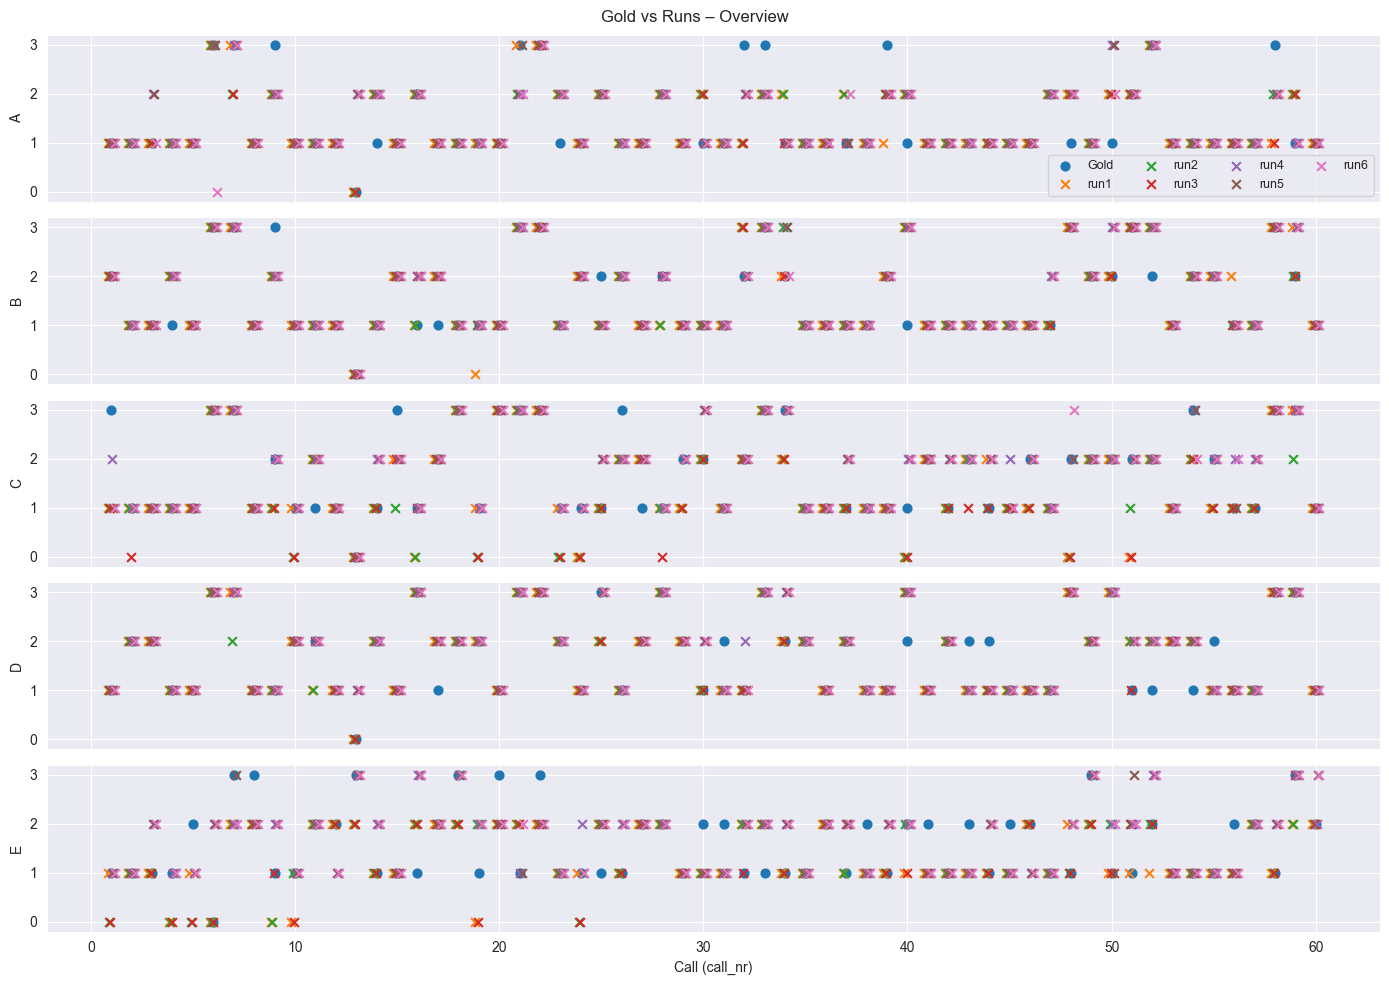

In [8]:
long_df = ev.wide_to_long_runs(df)
ev.plot_runs_vs_gold_big(long_df, title="Gold vs Runs – Overview")

In [9]:
long_df.to_csv("long_results_3.csv", index=False)

In [15]:
long_err = ev.errors_wide_to_long(df)
summary = ev.summarize_errors(long_err)
summary

,type,run,domain,N,mean,median,sum,rmse
0,conf_error,1,A,60,0.564333,0.28,33.86,0.990364
1,conf_error,1,B,60,0.412833,0.22,24.77,0.645976
2,conf_error,1,C,60,0.636500,0.45,38.19,0.871270
3,conf_error,1,D,60,0.436333,0.26,26.18,0.641283
4,conf_error,1,E,60,0.774167,0.60,46.45,0.982745
5,conf_error,2,A,60,0.589667,0.28,35.38,0.956764
6,conf_error,2,B,60,0.404167,0.22,24.25,0.633055
7,conf_error,2,C,60,0.662500,0.38,39.75,1.017714
8,conf_error,2,D,60,0.475667,0.28,28.54,0.700828
9,conf_error,2,E,60,0.727667,0.61,43.66,0.918207


In [16]:
mean_conf_error_matrix = (
    summary[summary["type"] == "conf_error"]
    .pivot(index="run", columns="domain", values="mean")
    .sort_index()
)

mean_conf_error_matrix

domain,A,B,C,D,E
run,,,,,
1,0.564333,0.412833,0.636500,0.436333,0.774167
2,0.589667,0.404167,0.662500,0.475667,0.727667
3,0.602667,0.369667,0.652833,0.415333,0.723667
4,0.536667,0.402333,0.473667,0.369333,0.746333
5,0.513500,0.404333,0.494333,0.360500,0.757333
6,0.536000,0.396167,0.534667,0.355000,0.741500


In [17]:
mean_error_matrix = (
    summary[summary["type"] == "error"]
    .pivot(index="run", columns="domain", values="mean")
    .sort_index()
)

mean_error_matrix

domain,A,B,C,D,E
run,,,,,
1,0.550000,0.283333,0.666667,0.300000,0.900000
2,0.550000,0.250000,0.766667,0.350000,0.900000
3,0.566667,0.216667,0.750000,0.250000,0.866667
4,0.483333,0.266667,0.350000,0.283333,0.933333
5,0.433333,0.266667,0.366667,0.266667,0.900000
6,0.600000,0.250000,0.450000,0.266667,0.950000


In [18]:
total_per_run = (
    long_err
    .groupby(["type", "run"], as_index=False)
    .agg(
        N=("value", "count"),
        mean=("value", "mean"),
        sum=("value", "sum"),
        max=("value", "max"),
    )
    .sort_values(["type", "run"])
)
total_per_run

,type,run,N,mean,sum,max
0,conf_error,1,300,0.564833,169.45,4.44
1,conf_error,2,300,0.571933,171.58,4.44
2,conf_error,3,300,0.552833,165.85,4.44
3,conf_error,4,300,0.505667,151.70,2.85
4,conf_error,5,300,0.506000,151.80,3.00
5,conf_error,6,300,0.512667,153.80,3.00
6,error,1,300,0.540000,162.00,6.00
7,error,2,300,0.563333,169.00,6.00
8,error,3,300,0.530000,159.00,6.00
9,error,4,300,0.463333,139.00,3.00


In [19]:
df_totals = ev.total_error_per_run(df)
df_totals

,run,sum_error,sum_conf_error
0,1,162,169.45
1,2,169,171.58
2,3,159,165.85
3,4,139,151.70
4,5,134,151.80
5,6,151,153.80


In [20]:
df_cat = ev.error_summary_per_category(df)
df_cat

,domain,mean_error,sum_error,mean_conf_error,sum_conf_error
0,A,0.530556,191,0.557139,200.57
1,B,0.255556,92,0.398250,143.37
2,C,0.558333,201,0.575750,207.27
3,D,0.286111,103,0.402028,144.73
4,E,0.908333,327,0.745111,268.24


In [22]:
(df == 9).sum()


A                 0
A_1               0
A_1_conf          0
A_1_conf_error    0
A_1_error         0
                 ..
E_5_error         0
E_6               0
E_6_conf          0
E_6_conf_error    0
E_6_error         0
Length: 125, dtype: int64

In [23]:
import tiktoken

OUTPUT_CONTRACT_DEFAULT = """
Return ONLY valid JSON (no markdown, no commentary).

Schema:
{
  "severity": <int or null>,
  "confidence": <float 0..1 or null>,
  "findings": <list of strings>
}

Rules:
- findings must be short factual phrases grounded in the call text.
- if no findings are available, return [].
- do NOT invent findings.
""".strip()

guidelines =Path("guidelines/a_guidelines.md").read_text(encoding="utf-8")

text = guidelines + "\n\n" + OUTPUT_CONTRACT_DEFAULT



## Token zählen: 


encoding = tiktoken.get_encoding("o200k_base")

tokens = encoding.encode(text)

print("GPT 5.2:" , len(tokens))

GPT 5.2: 393


In [24]:
import anthropic
import pandas as pd
import requests
from dotenv import load_dotenv
from anthropic import Anthropic
import os

load_dotenv()
os.environ["ANTHROPIC_API_KEY"] = os.getenv("ANTHROPIC_API_KEY")
client = anthropic.Anthropic()

response = client.messages.count_tokens(
    model="claude-opus-4-6",
    messages=[{"role": "user", "content": text}],
)

print(response.json())

{"input_tokens":467}


/var/folders/9k/bqn5d5t90kl0x7z66fx4d0cw0000gn/T/ipykernel_23348/1825925790.py:17: PydanticDeprecatedSince20: The `json` method is deprecated; use `model_dump_json` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  print(response.json())


In [26]:
5 * 467

2335